# 05 — Follower Count Regression

This cross-sectional model describes association, not future growth or causality.

In [1]:
from pathlib import Path
import hashlib
import json
import warnings
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")
current = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (current, *current.parents) if (p / "config" / "config.yaml").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Cannot locate project root containing config/config.yaml")
with (PROJECT_ROOT / "config" / "config.yaml").open(encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

def project_path(key):
    return PROJECT_ROOT / CONFIG["paths"][key]

OUTPUT = project_path("output")
PROCESSED = project_path("processed")
for folder in [OUTPUT / "reports", OUTPUT / "figures", OUTPUT / "models", OUTPUT / "labeling", OUTPUT / "logs", OUTPUT / "powerbi", PROCESSED]:
    folder.mkdir(parents=True, exist_ok=True)
fingerprint_paths = [PROJECT_ROOT / "config" / "config.yaml", project_path("shops")]
for key in ("products", "reviews"):
    fingerprint_paths.extend(sorted(project_path(key).glob("shop_*.json")))
seller_candidate = project_path("seller_metrics")
for candidate in (seller_candidate, seller_candidate.with_suffix(".xlsx")):
    if candidate.exists(): fingerprint_paths.append(candidate)
digest = hashlib.sha256()
for path in fingerprint_paths:
    digest.update(str(path.relative_to(PROJECT_ROOT)).encode("utf-8")); digest.update(path.read_bytes())
INPUT_FINGERPRINT = digest.hexdigest()
print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_FINGERPRINT:", INPUT_FINGERPRINT)

PROJECT_ROOT: /app/workspace/shopee_dikw
INPUT_FINGERPRINT: 627926017fa4d7b3989d59d36d8011e24bec5fd3abc9e08aeae4b9185354d6eb


In [2]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

shops = pd.read_csv(PROCESSED / "shops_clean.csv")
auth_path = OUTPUT / "reports" / "Shop_Authenticity_Report.csv"
auth = pd.read_csv(auth_path)[["Shop_ID","Authentic_Review_Rate"]] if auth_path.exists() else pd.DataFrame({"Shop_ID":shops["Shop_ID"],"Authentic_Review_Rate":np.nan})
data = shops.drop(columns=["Authentic_Review_Rate"],errors="ignore").merge(auth,on="Shop_ID",how="left",validate="one_to_one")
features = CONFIG["regression"]["features"]; target = CONFIG["regression"]["target"]
for feature in features:
    if feature not in data: data[feature] = np.nan
numeric = data[features].apply(pd.to_numeric,errors="coerce")
coverage = pd.DataFrame({"Feature":features,"Observed_Count":[numeric[c].notna().sum() for c in features],"Observed_Rate":[numeric[c].notna().mean() for c in features],"Unique_Observed_Values":[numeric[c].nunique(dropna=True) for c in features]})
coverage["Usable"] = (coverage["Observed_Rate"] == 1.0) & (coverage["Unique_Observed_Values"] >= 2)
active_features = coverage.loc[coverage["Usable"],"Feature"].tolist(); excluded_features=[c for c in features if c not in active_features]
coverage.to_csv(OUTPUT/"reports"/"regression_feature_coverage.csv",index=False)
target_values = pd.to_numeric(data[target],errors="coerce"); data = data.loc[target_values.notna()].copy(); data[target] = target_values.loc[data.index]
REGRESSION_READY = len(data) >= 10 and bool(active_features)
readiness = pd.DataFrame([{"ready":REGRESSION_READY,"observed_target_rows":len(data),"active_features":", ".join(active_features),"excluded_features":", ".join(excluded_features),"blockers":"" if REGRESSION_READY else "Need at least 10 observed targets and one complete varying feature"}])
readiness.to_csv(OUTPUT/"reports"/"regression_readiness.csv",index=False); display(readiness)
if REGRESSION_READY:
    x_train,x_test,y_train,y_test=train_test_split(data[active_features],data[target],test_size=max(3,int(np.ceil(len(data)*.2))),random_state=CONFIG["project"]["random_state"])
    model=LinearRegression().fit(x_train,y_train); prediction=model.predict(x_test)
    x_scaler,y_scaler=StandardScaler(),StandardScaler(); standardized=LinearRegression().fit(x_scaler.fit_transform(data[active_features]),y_scaler.fit_transform(data[[target]]).ravel())
    coefficients=pd.DataFrame({"Feature":active_features,"Coefficient":model.coef_,"Standardized_Coefficient":standardized.coef_}); coefficients["Direction"]=np.where(coefficients["Coefficient"]>=0,"positive","negative"); coefficients["Absolute_Standardized_Coefficient"]=coefficients["Standardized_Coefficient"].abs()
    metrics={"input_fingerprint":INPUT_FINGERPRINT,"active_features":active_features,"excluded_features":excluded_features,"sample_size":len(data),"train_rows":len(x_train),"test_rows":len(x_test),"MAE":mean_absolute_error(y_test,prediction),"RMSE":mean_squared_error(y_test,prediction)**.5,"R2":r2_score(y_test,prediction)}
    quality_warnings=[]
    if excluded_features: quality_warnings.append("Required features unavailable: " + ", ".join(excluded_features))
    if len(data) < 30: quality_warnings.append(f"Only {len(data)} shops; holdout metrics are unstable and coefficients are exploratory")
    if metrics["R2"] <= 0: quality_warnings.append("Negative test R2; model is worse than predicting the test-set mean")
    metrics["quality_acceptable"] = not quality_warnings
    metrics["interpretation_status"] = "validated" if metrics["quality_acceptable"] else "exploratory_only"
    metrics["quality_warnings"] = quality_warnings
else:
    print("REGRESSION BLOCKED — no model or metrics were fabricated.")

,ready,observed_target_rows,active_features,excluded_features,blockers
0,True,15,"Years_Active, Total_Products, Rating_Average, ...",Conversion_Rate_pct,


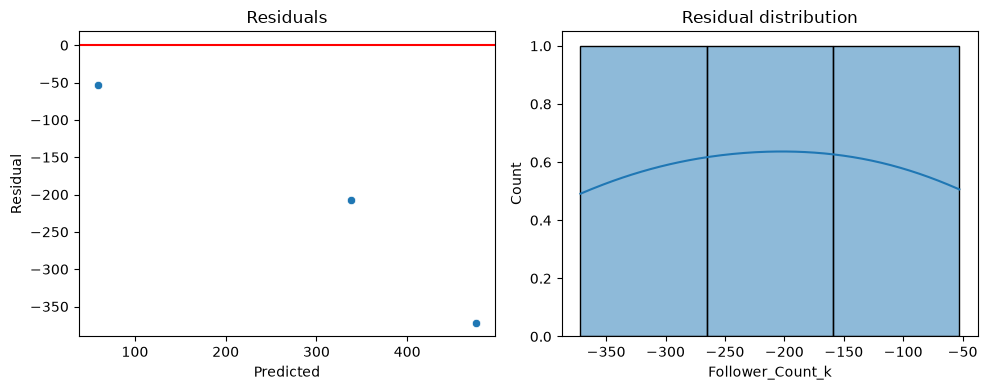

,Feature,Coefficient,Standardized_Coefficient,Direction,Absolute_Standardized_Coefficient
1,Total_Products,0.015098,0.880184,positive,0.880184
0,Years_Active,156.291364,0.201600,positive,0.201600
3,Chat_Response_Rate_pct,14.017199,0.089665,positive,0.089665
4,Authentic_Review_Rate,-1.733451,-0.014403,negative,0.014403
2,Rating_Average,1.521768,-0.006426,positive,0.006426


,input_fingerprint,active_features,excluded_features,sample_size,train_rows,test_rows,MAE,RMSE,R2,quality_acceptable,interpretation_status,quality_warnings
0,627926017fa4d7b3989d59d36d8011e24bec5fd3abc9e0...,"[Years_Active, Total_Products, Rating_Average,...",[Conversion_Rate_pct],15,12,3,210.483264,247.488987,-20.166444,False,exploratory_only,[Required features unavailable: Conversion_Rat...


,Feature_A,Feature_B,Absolute_Correlation
0,Rating_Average,Chat_Response_Rate_pct,0.825093


In [3]:
if REGRESSION_READY:
    residuals=y_test-prediction
    fig,axes=plt.subplots(1,2,figsize=(10,4)); sns.scatterplot(x=prediction,y=residuals,ax=axes[0]); axes[0].axhline(0,color="red"); axes[0].set(xlabel="Predicted",ylabel="Residual",title="Residuals"); sns.histplot(residuals,kde=True,ax=axes[1]); axes[1].set_title("Residual distribution"); fig.tight_layout(); fig.savefig(OUTPUT/"figures"/"regression_residuals.png",dpi=160); plt.show(); plt.close(fig)
    corr=data[active_features].corr().abs(); high=[]
    for i,a in enumerate(active_features):
        for b in active_features[i+1:]:
            if corr.loc[a,b]>=.8: high.append({"Feature_A":a,"Feature_B":b,"Absolute_Correlation":corr.loc[a,b]})
    coefficients.to_csv(OUTPUT/"reports"/"Regression_Result.csv",index=False); pd.DataFrame(high,columns=["Feature_A","Feature_B","Absolute_Correlation"]).to_csv(OUTPUT/"reports"/"regression_multicollinearity_flags.csv",index=False)
    pd.DataFrame([{"training_ready":True,"quality_acceptable":metrics["quality_acceptable"],"sample_size":len(data),"R2":metrics["R2"],"warnings":"; ".join(quality_warnings)}]).to_csv(OUTPUT/"reports"/"regression_quality.csv",index=False)
    (OUTPUT/"reports"/"regression_metrics.json").write_text(json.dumps(metrics,indent=2),encoding="utf-8")
    display(coefficients.sort_values("Absolute_Standardized_Coefficient",ascending=False)); display(pd.DataFrame([metrics])); display(pd.DataFrame(high))